
# Exploratory Data Analysis (EDA) — Student Success Prediction

This notebook performs a clean, reproducible EDA on the **Student Success Prediction** dataset.  
Goals:
- Load and inspect the training and test data
- Understand variable types, missingness and basic distributions
- Explore the target `Progress` (1 to 5)
- Get quick categorical and numeric insights to inform feature engineering


## 1. Setup

In [1]:

# Standard imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup complete.")

Setup complete.


## 2. Load Data

In [2]:

def find_path(basenames, extra_candidates=None):
    """Return the first existing path from candidate basenames searched across common dirs."""
    search_dirs = [".", "./data", os.getcwd(), "/mnt/data"]
    if extra_candidates:
        search_dirs.extend(extra_candidates)
    for d in search_dirs:
        for b in basenames:
            p = os.path.join(d, b)
            if os.path.exists(p):
                return p
    return None

train_candidates = ["train.csv"]
test_candidates = ["test.csv"]

train_path = find_path(train_candidates)
test_path = find_path(test_candidates)

print("Resolved train path:", train_path)
print("Resolved test path :", test_path)

if train_path is None or test_path is None:
    raise FileNotFoundError("Could not find train.csv/test.csv. Place them next to this notebook or in ./data/.")

# Read data
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape, "| Test shape:", test.shape)
train.head()

Resolved train path: .\train.csv
Resolved test path : .\test.csv
Train shape: (80532, 14) | Test shape: (34512, 13)


,Industry,Company,Opportunity,Candidate,Gender,Age,Race,Institution,Aggregate,Qualification,Disciplines,Progress,Successful,NumCandidates
0,Banking (Commercial & Retail),Client C,3,4,Female,22,Black,University of Johannesburg,89,Bachelor of Science,"Computer Science, Information Technology",1,False,357
1,Legal,Client B,2,5,Female,27,Black,University of Johannesburg,68,Bachelor of Laws,Law,1,False,1443
2,Legal,Client B,2,6,Female,24,Black,University of Limpopo,70,Bachelor of Laws,Law,1,False,1443
3,Legal,Client B,2,10,Female,21,Black,University of the Western Cape,66,Bachelor of Laws,Law,1,False,1443
4,Banking (Commercial & Retail),Client C,4,11,Female,25,Black,North-West University,65,Bachelor of Commerce (Honours),"Economics, Risk Management",5,False,503


## 3. Basic Overview

In [3]:

print("Columns:", list(train.columns))
print("\nDtypes:")
print(train.dtypes)

print("\nFirst rows:")
display(train.head())

print("\nLast rows:")
display(train.tail())

print("\nUnique row identifier columns (guess):")
candidates = [c for c in train.columns if c.lower() in ("id", "candidateid", "row_id")]
print(candidates if candidates else "None detected")

Columns: ['Industry', 'Company', 'Opportunity', 'Candidate', 'Gender', 'Age', 'Race', 'Institution', 'Aggregate', 'Qualification', 'Disciplines', 'Progress', 'Successful', 'NumCandidates']

Dtypes:
Industry         object
Company          object
Opportunity       int64
Candidate         int64
Gender           object
Age               int64
Race             object
Institution      object
Aggregate         int64
Qualification    object
Disciplines      object
Progress          int64
Successful         bool
NumCandidates     int64
dtype: object

First rows:


,Industry,Company,Opportunity,Candidate,Gender,Age,Race,Institution,Aggregate,Qualification,Disciplines,Progress,Successful,NumCandidates
0,Banking (Commercial & Retail),Client C,3,4,Female,22,Black,University of Johannesburg,89,Bachelor of Science,"Computer Science, Information Technology",1,False,357
1,Legal,Client B,2,5,Female,27,Black,University of Johannesburg,68,Bachelor of Laws,Law,1,False,1443
2,Legal,Client B,2,6,Female,24,Black,University of Limpopo,70,Bachelor of Laws,Law,1,False,1443
3,Legal,Client B,2,10,Female,21,Black,University of the Western Cape,66,Bachelor of Laws,Law,1,False,1443
4,Banking (Commercial & Retail),Client C,4,11,Female,25,Black,North-West University,65,Bachelor of Commerce (Honours),"Economics, Risk Management",5,False,503



Last rows:


,Industry,Company,Opportunity,Candidate,Gender,Age,Race,Institution,Aggregate,Qualification,Disciplines,Progress,Successful,NumCandidates
80527,Legal,Client E,20,36204,Female,19,Black,University of Johannesburg,70,Bachelor of Laws,Law,1,False,1615
80528,Legal,Client F,14,36204,Female,22,Black,University of Johannesburg,70,Bachelor of Laws,Law,1,False,2624
80529,Legal,Client A,69,2264,Female,25,Black,University of South Africa,77,Bachelor of Laws,Law,1,False,3176
80530,Legal,Client A,39,2264,Female,26,Black,University of South Africa,77,Bachelor of Laws,Law,1,False,3117
80531,Legal,Client F,9,2264,Female,26,Black,University of South Africa,77,Bachelor of Laws,Law,1,False,1923



Unique row identifier columns (guess):
None detected


## 4. Missingness

,missing,missing_pct
Race,1084,1.35
Gender,1045,1.30
Industry,512,0.64
Disciplines,378,0.47
Qualification,46,0.06
Institution,45,0.06


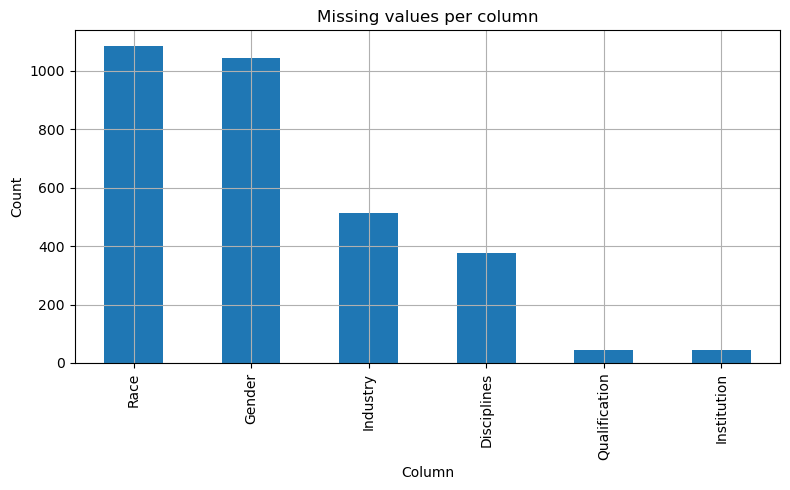

In [4]:

na_counts = train.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(train) * 100).round(2)
missing_df = pd.DataFrame({"missing": na_counts, "missing_pct": na_pct})
display(missing_df[missing_df["missing"] > 0])

# Bar chart of missing
nonzero = missing_df[missing_df["missing"] > 0]
if not nonzero.empty:
    plt.figure()
    nonzero["missing"].plot(kind="bar")
    plt.title("Missing values per column")
    plt.xlabel("Column")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 5. Target: `Progress`

Descriptive stats for Progress
count    80532.000000
mean         1.473216
std          0.882579
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: Progress, dtype: float64


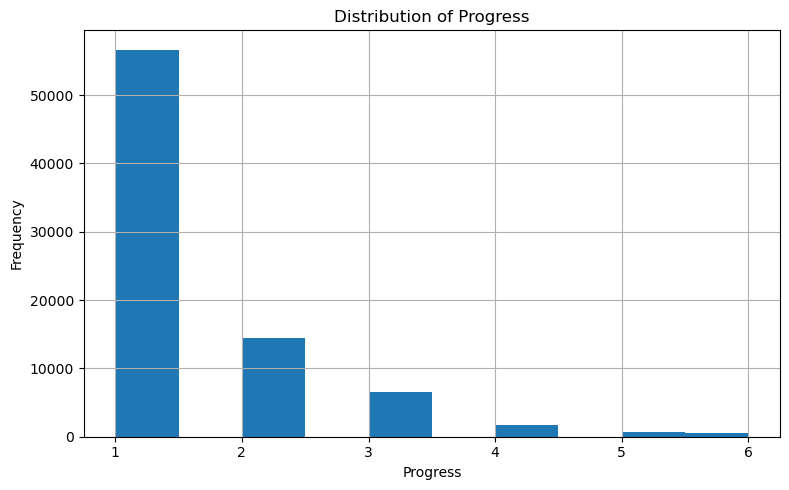

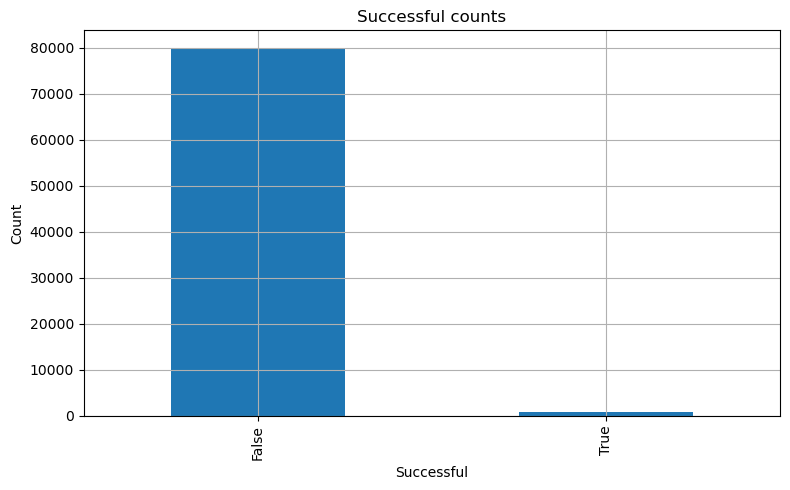

In [5]:

target_col = "Progress"
if target_col in train.columns:
    print("Descriptive stats for Progress")
    print(train[target_col].describe())

    # Histogram of Progress
    plt.figure()
    train[target_col].dropna().plot(kind="hist", bins=10)
    plt.title("Distribution of Progress")
    plt.xlabel("Progress")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # If a Success or Successful indicator exists, show it too
    for s in ("Success", "Successful"):
        if s in train.columns:
            plt.figure()
            train[s].value_counts().sort_index().plot(kind="bar")
            plt.title(f"{s} counts")
            plt.xlabel(s)
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()
else:
    print("No 'Progress' column found.")

## 6. Categorical Variables — Top Frequencies

,Institution,count
0,University of South Africa,9832
1,University of the Witwatersrand,9556
2,University of Pretoria,8788
3,University of Johannesburg,7429
4,University of KwaZulu-Natal,5855
5,University of the Free State,4839
6,University of the Western Cape,4632
7,North-West University,4605
8,University of Cape Town,4201
9,Stellenbosch University,1989


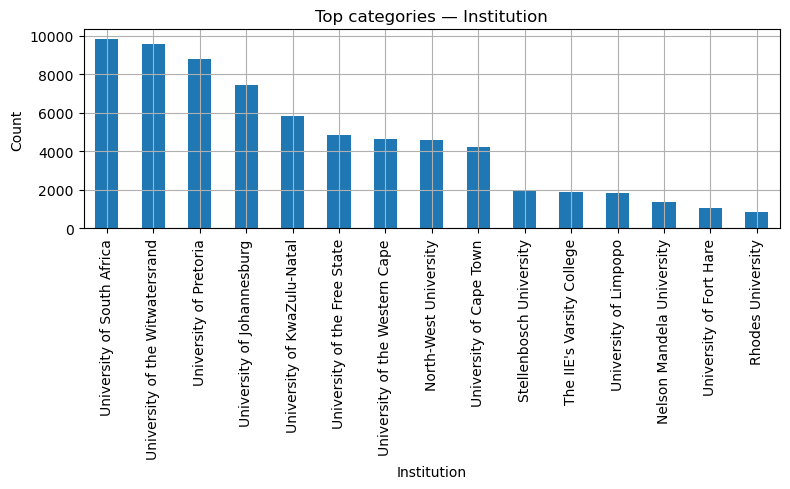

,Qualification,count
0,Bachelor of Laws,41750
1,Bachelor of Commerce,6069
2,Bachelor of Science,5228
3,Bachelor of Commerce (Honours),4989
4,Bachelor of Science (Honours),3219
5,Master of Laws,3215
6,Bachelor of Arts,2506
7,Postgraduate Diploma,2293
8,Advanced Diploma,1036
9,Master of Commerce,838


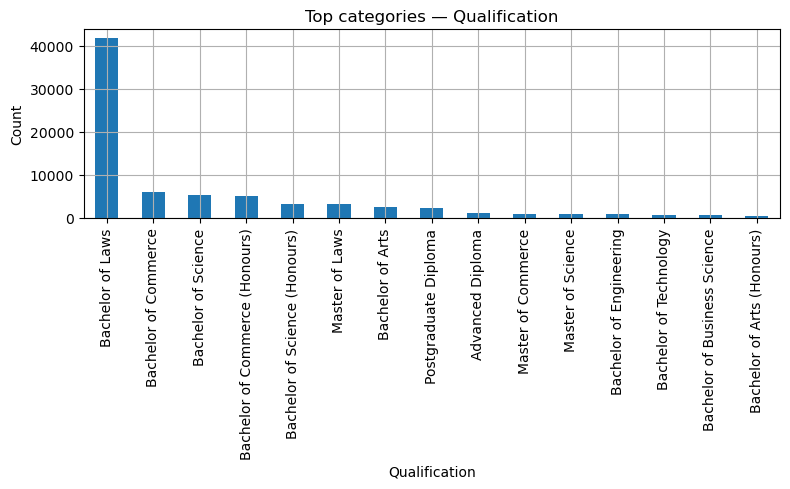

,Company,count
0,Client E,13353
1,Client C,12027
2,Client A,10499
3,Client L,7880
4,Client P,7094
5,Client F,6789
6,Client I,6067
7,Client J,4959
8,Client B,2561
9,Client H,1771


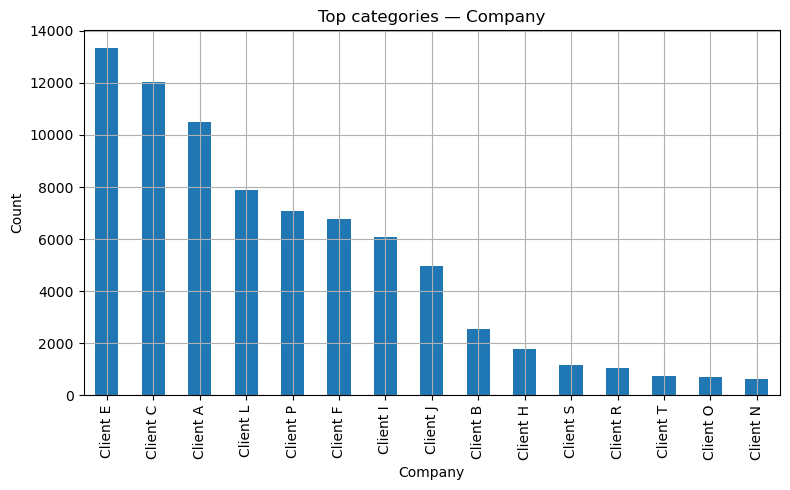

,Opportunity,count
0,35,2418
1,29,2384
2,1,2368
3,31,2344
4,8,2339
5,7,2321
6,76,2252
7,69,2238
8,39,2176
9,37,2126


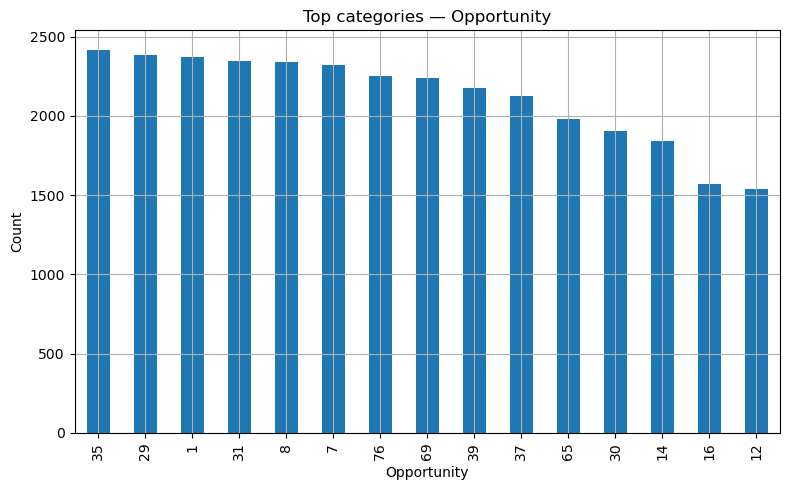

,Gender,count
0,Female,47891
1,Male,31522
2,Other,74


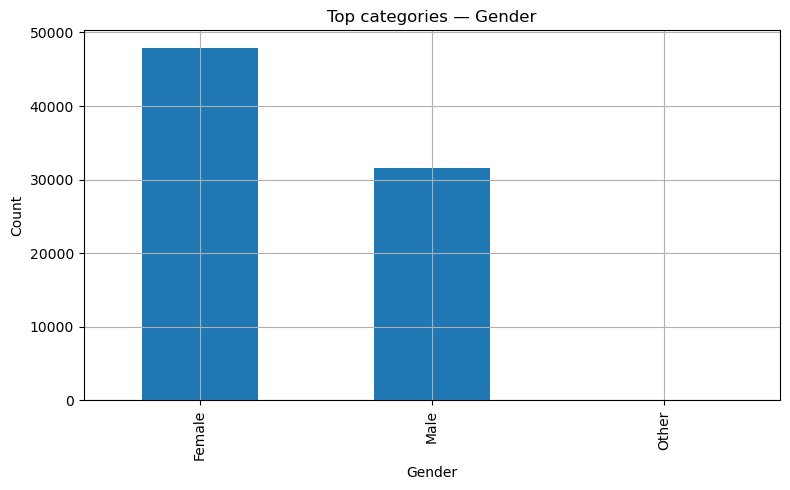

,Race,count
0,Black,59693
1,White,7537
2,Indian,6531
3,Coloured,4875
4,Other,434
5,Asian,291
6,Indian/Asian,87


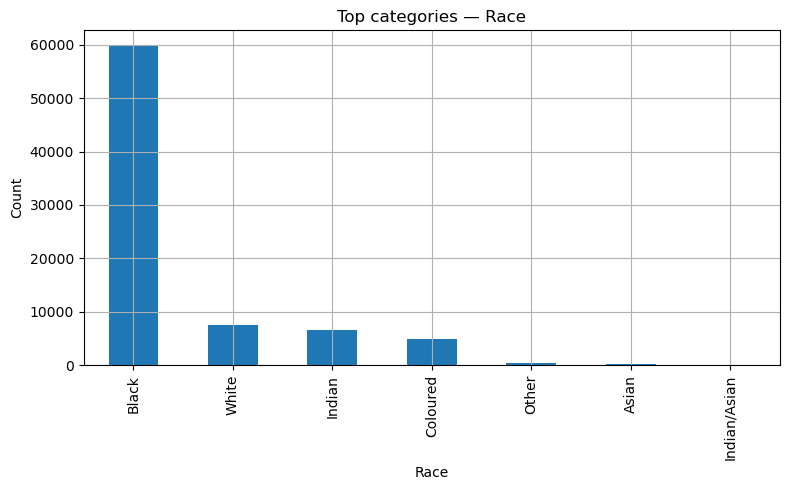

In [6]:

# Choose a few known categorical columns if present
candidate_cats = [
    "Institution", "Qualification", "Company", "Opportunity", "Gender", "Race"
]
for col in candidate_cats:
    if col in train.columns:
        vc = train[col].value_counts().head(15)
        display(pd.DataFrame({col: vc.index, "count": vc.values}))
        plt.figure()
        vc.plot(kind="bar")
        plt.title(f"Top categories — {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

## 7. Numeric Variables — Distributions

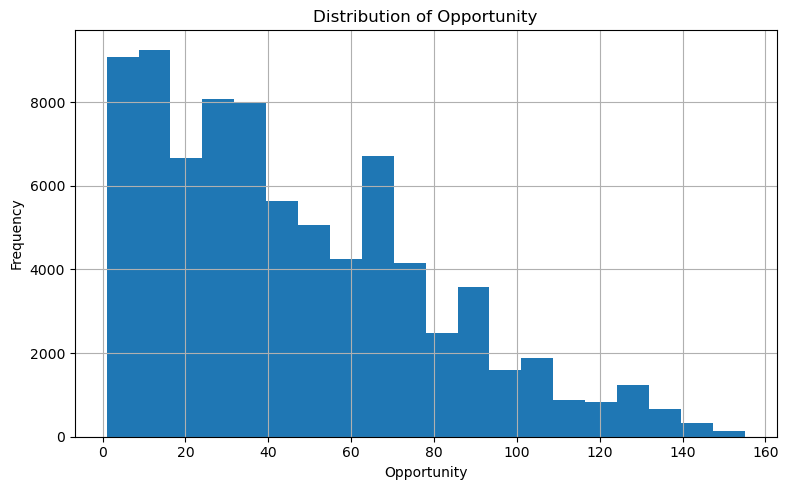

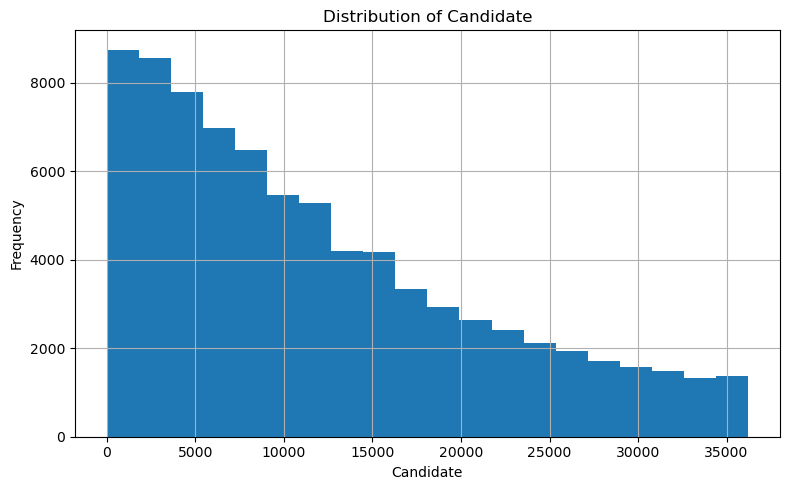

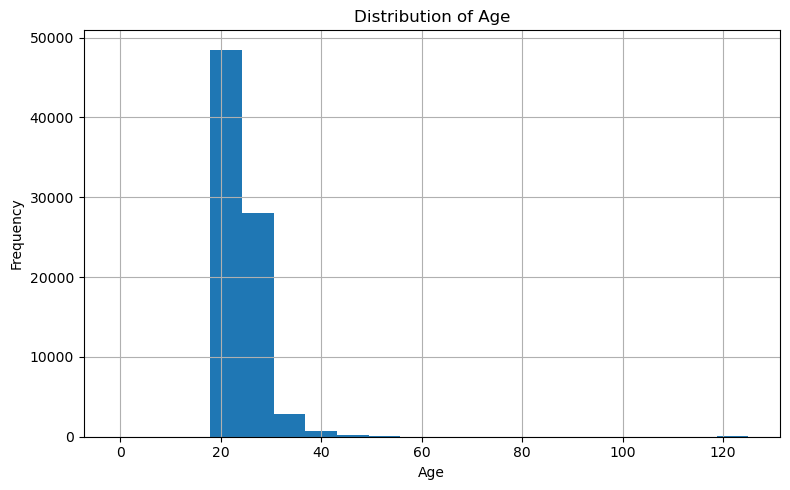

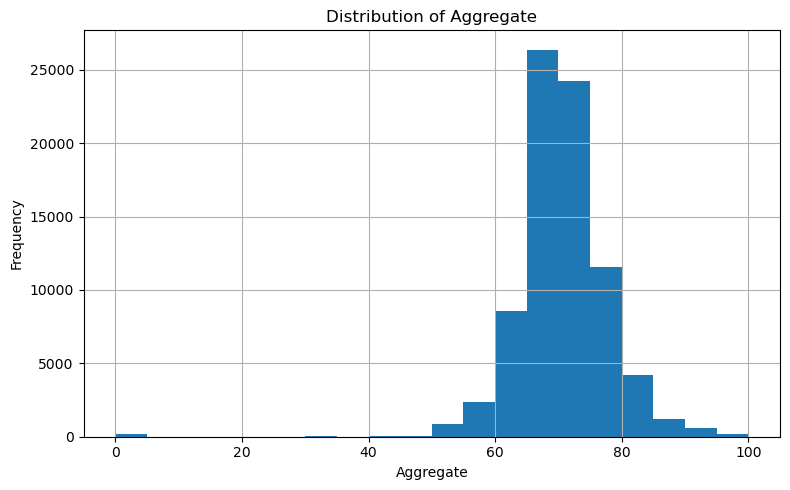

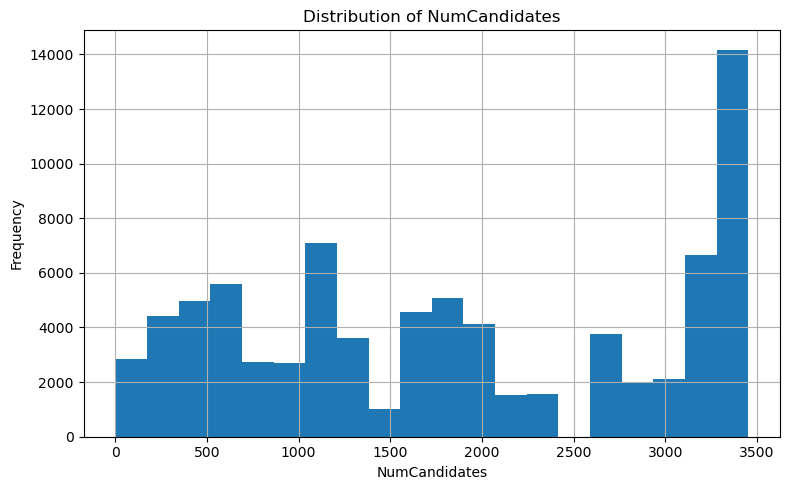

In [7]:

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# remove target to avoid redundancy here
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

for col in numeric_cols[:8]:  # cap to a few plots for brevity
    plt.figure()
    train[col].dropna().plot(kind="hist", bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 8. Bivariate Relationships with `Progress`

,pearson_corr_with_Progress
Candidate,0.143845
Opportunity,0.138158
Aggregate,0.052182
NumCandidates,-0.028200
Age,-0.046257


,pearson_corr_with_Progress
Candidate,0.143845
Opportunity,0.138158
Aggregate,0.052182
NumCandidates,-0.028200
Age,-0.046257


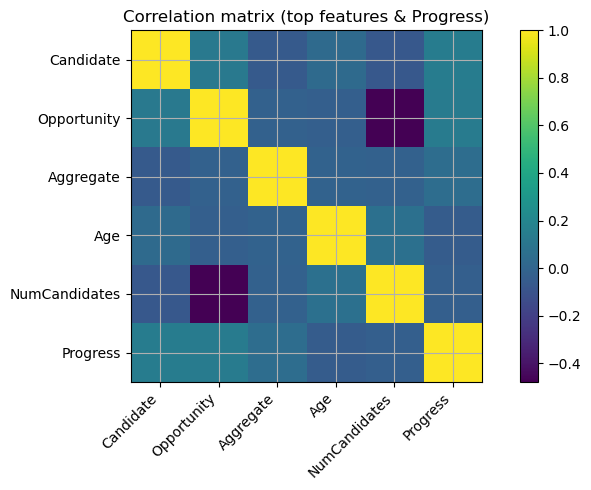

,mean_Progress
Industry,
IT & Telecommunications,2.457310
Banking (Commercial & Retail),1.687255
Insurance,1.554113
Financial services,1.509221
Accounting & Finance,1.502283
Asset Management,1.416260
Legal,1.250905
Retail,1.083994


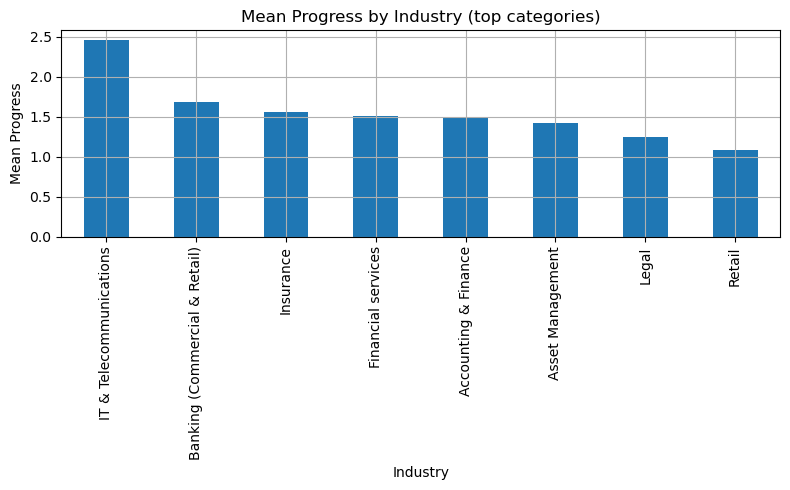

,mean_Progress
Company,
Client I,2.549530
Client P,2.217226
Client J,1.600323
Client C,1.374657
Client A,1.298124
Client E,1.221523
Client L,1.188959
Client F,1.128001


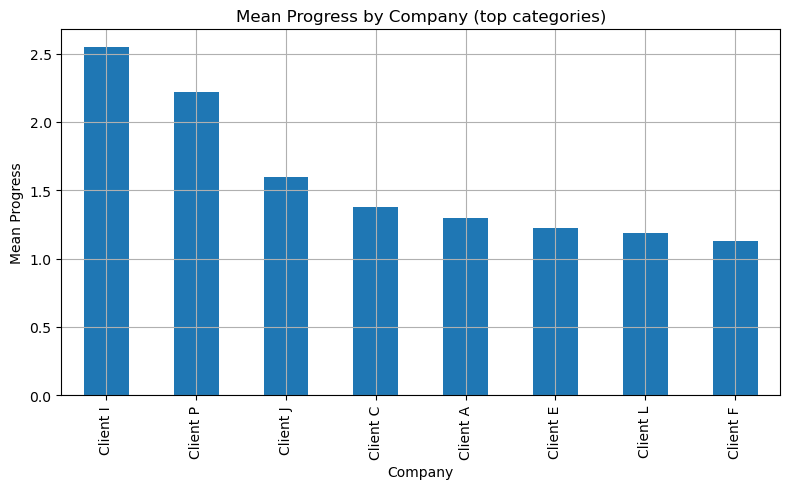

,mean_Progress
Gender,
Male,1.510215
Other,1.459459
Female,1.453572


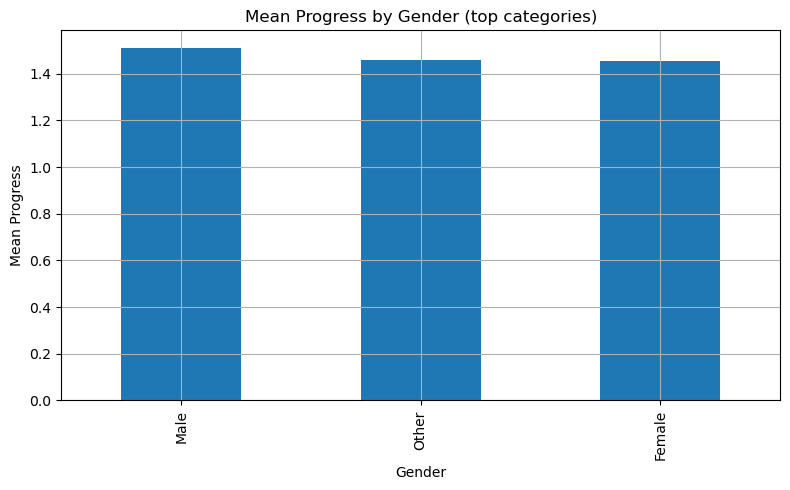

,mean_Progress
Race,
Indian/Asian,1.574713
Asian,1.560137
Other,1.536866
Indian,1.487521
White,1.478705
Black,1.476572
Coloured,1.438769


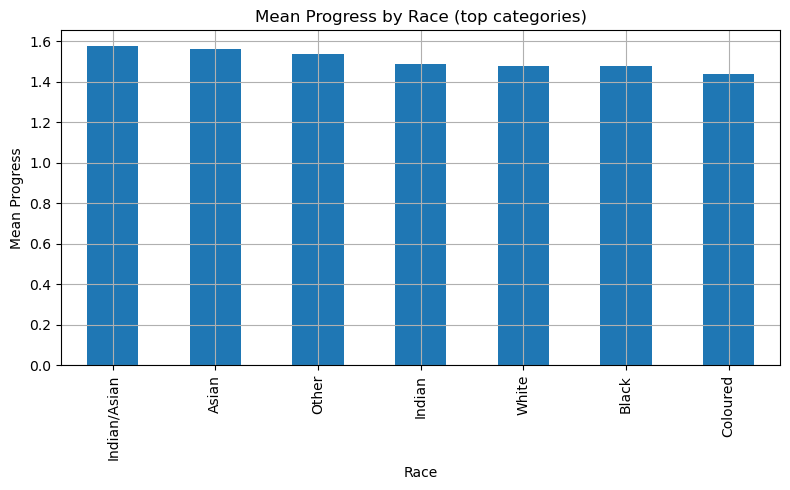

,mean_Progress
Institution,
University of Johannesburg,1.542873
University of the Witwatersrand,1.518522
University of KwaZulu-Natal,1.458924
University of Pretoria,1.450387
North-West University,1.446688
University of the Free State,1.349866
University of the Western Cape,1.332686
University of South Africa,1.211147


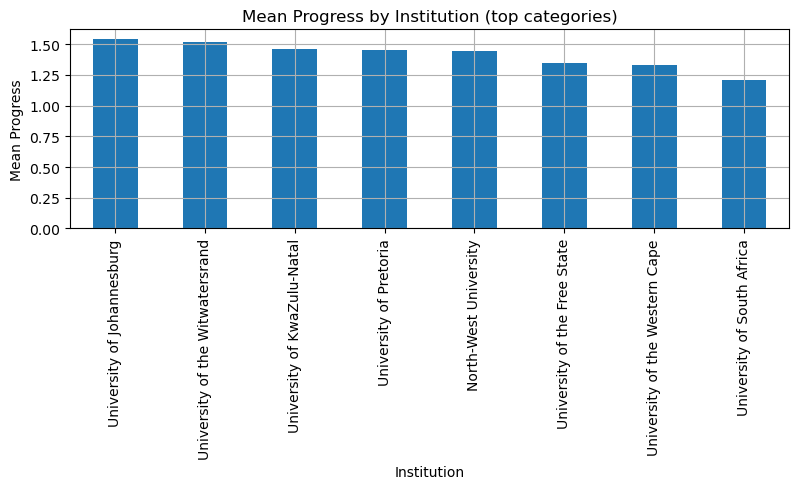

In [8]:

if target_col in train.columns:
    # numeric vs target: correlation
    numcols = train.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numcols:
        numcols.remove(target_col)
    corrs = {}
    for col in numcols:
        # Pearson correlation with naive dropna alignment
        df_pair = train[[col, target_col]].dropna()
        if len(df_pair) > 1:
            corrs[col] = df_pair[col].corr(df_pair[target_col])
    if corrs:
        corr_series = pd.Series(corrs).sort_values(ascending=False)
        display(corr_series.to_frame("pearson_corr_with_Progress").head(15))
        display(corr_series.to_frame("pearson_corr_with_Progress").tail(15))

        # Quick correlation heatmap for top correlated numeric features
        top_cols = [c for c in corr_series.abs().sort_values(ascending=False).head(8).index]
        if top_cols:
            df_top = train[top_cols + [target_col]].dropna()
            if df_top.shape[1] > 1 and df_top.shape[0] > 1:
                corr_mat = df_top.corr()
                plt.figure()
                plt.imshow(corr_mat, interpolation="nearest")
                plt.title("Correlation matrix (top features & Progress)")
                plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=45, ha="right")
                plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
                plt.colorbar()
                plt.tight_layout()
                plt.show()

    # simple category vs target: mean Progress by top categories
    catcols = [c for c in train.columns if train[c].dtype == "object"]
    for col in catcols[:5]:
        vc = train[col].value_counts().head(8).index.tolist()
        subset = train[train[col].isin(vc)]
        if not subset.empty:
            grp = subset.groupby(col)[target_col].mean().sort_values(ascending=False)
            display(grp.to_frame("mean_Progress"))
            plt.figure()
            grp.plot(kind="bar")
            plt.title(f"Mean Progress by {col} (top categories)")
            plt.xlabel(col)
            plt.ylabel("Mean Progress")
            plt.tight_layout()
            plt.show()

## 9. Train vs Test — Schema Check

In [9]:

train_only = sorted(set(train.columns) - set(test.columns))
test_only = sorted(set(test.columns) - set(train.columns))
print("Columns only in TRAIN:", train_only)
print("Columns only in TEST :", test_only)

# Basic sanity on ID and required fields for submission
id_guess = None
for cand in ("ID", "Id", "id", "CandidateID", "Row_ID"):
    if cand in test.columns:
        id_guess = cand
        break
print("Likely test ID column:", id_guess)

Columns only in TRAIN: ['Progress', 'Successful']
Columns only in TEST : ['ID']
Likely test ID column: ID


## 10. Notes & Next Steps

- Summarize key findings here.
- Identify columns with high missingness and plan imputation/encoding.
- Draft a feature plan for modeling.

*Generated on:* 2025-08-28 10:26:03